# 📈 Unemployment Analysis with Python

This project performs Exploratory Data Analysis (EDA) on unemployment data in India. It examines unemployment rate trends, regional distributions, rural vs. urban contrasts, and measures the impact of the **COVID-19 pandemic and subsequent lockdown (2020)** on the labor market.

## 📊 Datasets
We use two datasets for this analysis:
1. `Unemployment in India.csv`: Contains state-wise monthly unemployment statistics, segmented by `Area` (Rural / Urban).
2. `Unemployment_Rate_upto_11_2020.csv`: Contains state-wise monthly unemployment statistics, segmented by division `Region` (North, South, West, East, Northeast) and geographical coordinates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [2]:
# Load datasets
df_india = pd.read_csv("Unemployment in India.csv")
df_rate = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print(f"Unemployment in India shape: {df_india.shape}")
print(f"Unemployment Rate upto 11/2020 shape: {df_rate.shape}")

Unemployment in India shape: (768, 7)
Unemployment Rate upto 11/2020 shape: (267, 9)


In [3]:
# Clean column names (remove leading/trailing spaces)
df_india.columns = df_india.columns.str.strip()
df_rate.columns = df_rate.columns.str.strip()

# Drop rows where all elements are NaN (handles trailing empty lines in CSV)
df_india = df_india.dropna(subset=['Region'])
df_rate = df_rate.dropna(subset=['Region'])

# Parse dates
df_india['Date'] = pd.to_datetime(df_india['Date'].str.strip(), format='%d-%m-%Y', errors='coerce')
df_rate['Date'] = pd.to_datetime(df_rate['Date'].str.strip(), format='%d-%m-%Y', errors='coerce')

# Extract Month and Year
df_india['Month_Name'] = df_india['Date'].dt.strftime('%B')
df_india['Year'] = df_india['Date'].dt.year.astype('Int64')

df_rate['Month_Name'] = df_rate['Date'].dt.strftime('%B')
df_rate['Year'] = df_rate['Date'].dt.year.astype('Int64')

print(f"Cleaned Unemployment in India shape: {df_india.shape}")
print(f"Cleaned Unemployment Rate upto 11/2020 shape: {df_rate.shape}")

Cleaned Unemployment in India shape: (740, 9)
Cleaned Unemployment Rate upto 11/2020 shape: (267, 11)


In [4]:
# Basic info & missing values
print("=== Unemployment in India Info ===")
df_india.info()
print("\nMissing values:\n", df_india.isnull().sum())

print("\n=== Unemployment Rate Upto 11/2020 Info ===")
df_rate.info()
print("\nMissing values:\n", df_rate.isnull().sum())

=== Unemployment in India Info ===
<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
 7   Month_Name                               740 non-null    str           
 8   Year                                     740 non-null    Int64         
dtypes: Int64(1), datetime64[u

## 📊 Exploratory Data Analysis (EDA)
Let's look at average unemployment rates, correlations, and compare rural vs. urban areas.

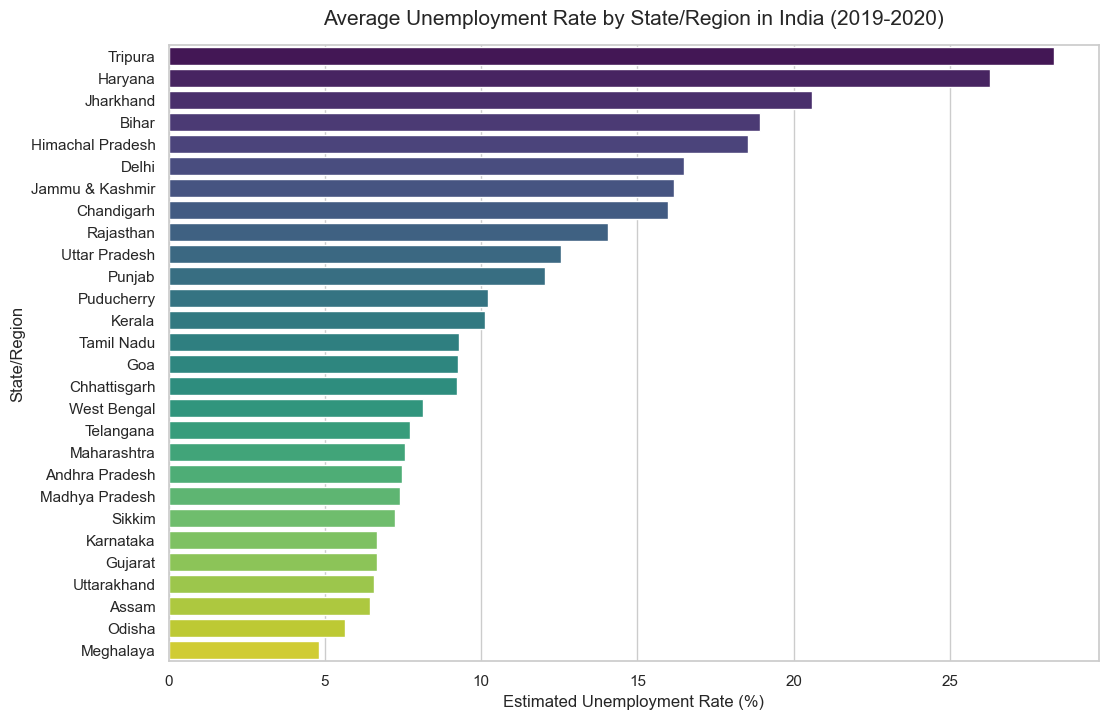

In [5]:
# 1. State-wise Average Unemployment Rate (using Unemployment in India.csv)
state_unemp = df_india.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=state_unemp, y='Region', x='Estimated Unemployment Rate (%)', palette='viridis', hue='Region', legend=False)
plt.title("Average Unemployment Rate by State/Region in India (2019-2020)", fontsize=15, pad=15)
plt.xlabel("Estimated Unemployment Rate (%)", fontsize=12)
plt.ylabel("State/Region", fontsize=12)
plt.savefig("average_unemployment_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

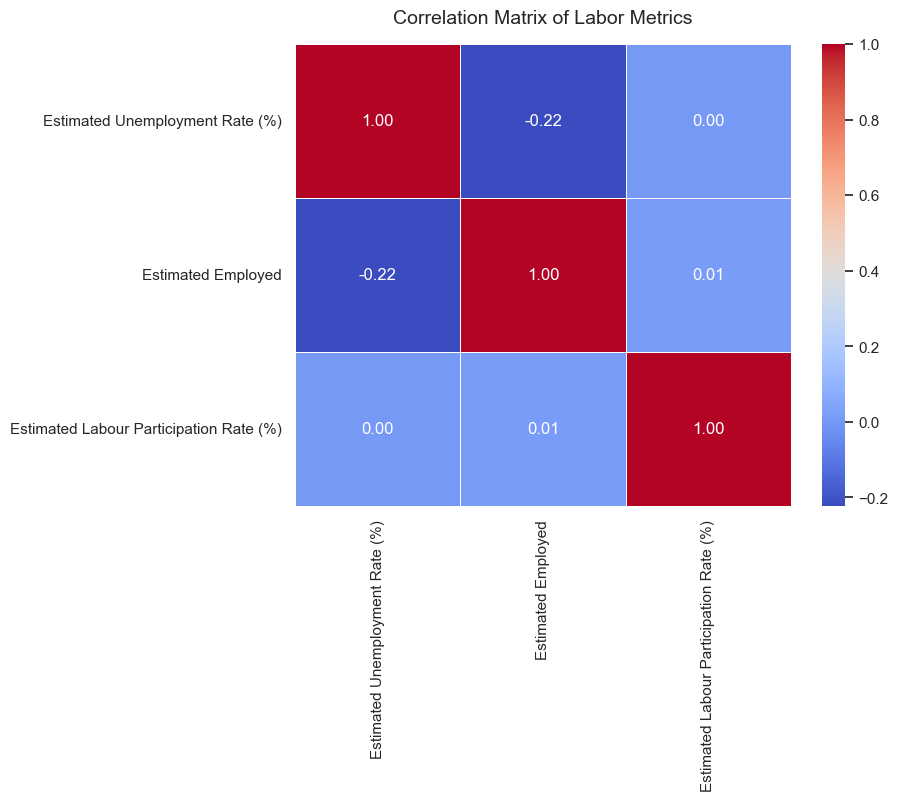

In [6]:
# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
sns.heatmap(df_india[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Labor Metrics", fontsize=14, pad=15)
plt.savefig("labor_metrics_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

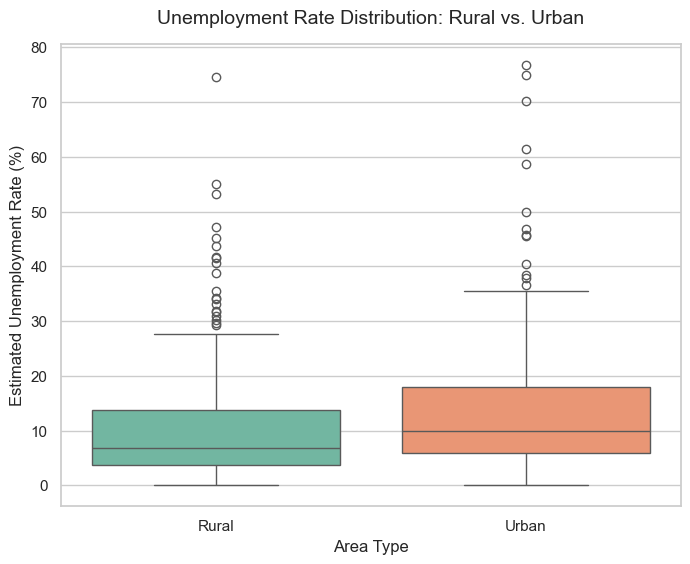

--- Summary Stats by Area ---
       count       mean        std  min   25%   50%     75%    max
Area                                                              
Rural  359.0  10.324791  10.038895  0.0  3.79  6.76  13.755  74.51
Urban  381.0  13.166614  11.165444  0.0  5.82  9.97  18.040  76.74


In [7]:
# 3. Rural vs. Urban Area Unemployment Rate
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_india, x='Area', y='Estimated Unemployment Rate (%)', palette='Set2', hue='Area', legend=False)
plt.title("Unemployment Rate Distribution: Rural vs. Urban", fontsize=14, pad=15)
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=12)
plt.xlabel("Area Type", fontsize=12)
plt.savefig("rural_vs_urban_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

print("--- Summary Stats by Area ---")
print(df_india.groupby('Area')['Estimated Unemployment Rate (%)'].describe())

Columns in df_rate: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude', 'Month_Name', 'Year']
Division Column: Region.1
Unique divisions: <StringArray>
['South', 'Northeast', 'East', 'West', 'North']
Length: 5, dtype: str


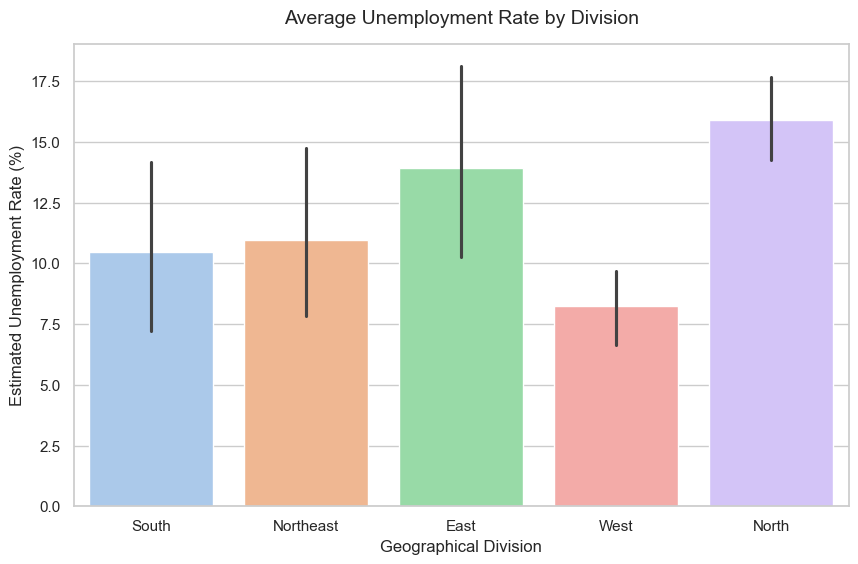

In [8]:
# 4. Division-wise (Regional Division) Average Unemployment Rate (using Unemployment_Rate_upto_11_2020.csv)
# Note: The second dataset contains 'Region.1' or similar column for division, let's identify the columns first
print("Columns in df_rate:", df_rate.columns.tolist())

# In df_rate, the columns are ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
#  'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']
# Let's rename 'Region.1' to 'Division' if it exists or use index
cols = df_rate.columns.tolist()
if len([c for c in cols if c == 'Region']) > 1:
    # Pandas automatically renames duplicate columns by appending suffix like .1
    pass

# Let's inspect unique values of division column (usually the 7th column, index 6)
division_col = df_rate.columns[6]
print(f"Division Column: {division_col}")
print("Unique divisions:", df_rate[division_col].unique())

plt.figure(figsize=(10, 6))
sns.barplot(data=df_rate, x=division_col, y='Estimated Unemployment Rate (%)', palette='pastel', hue=division_col, legend=False)
plt.title("Average Unemployment Rate by Division", fontsize=14, pad=15)
plt.xlabel("Geographical Division", fontsize=12)
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=12)
plt.savefig("unemployment_by_division.png", dpi=300, bbox_inches="tight")
plt.show()

## 🦠 COVID-19 Lockdown Impact Analysis
India declared a nationwide lockdown on **March 24, 2020**. Let's segment the data into:
- **Pre-Lockdown:** Before April 2020
- **Lockdown Period:** April 2020 to July 2020 (impact peak)
- **Post-Lockdown Recovery:** August 2020 onwards

                   Period  Estimated Unemployment Rate (%)
0            Pre-Lockdown                         9.761519
1           Lockdown Peak                        16.503458
2  Post-Lockdown Recovery                         9.015185


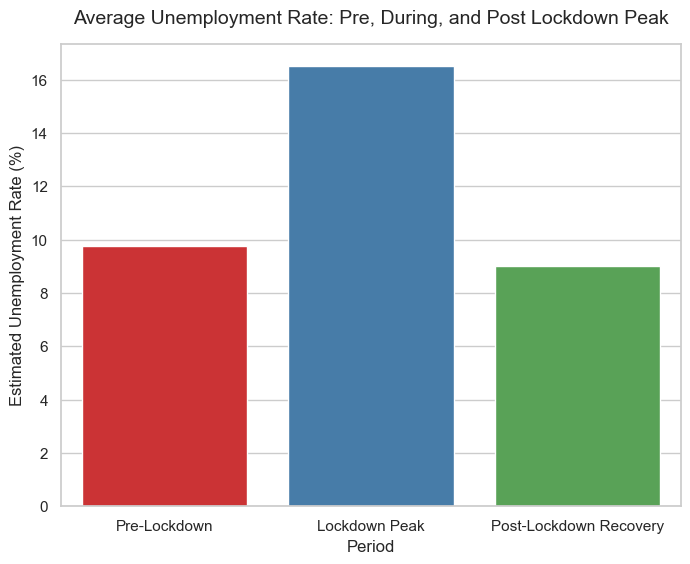

In [9]:
# We will use df_rate since it spans dates from Jan 2020 to Oct 2020
def classify_period(date):
    if date < pd.Timestamp('2020-04-01'):
        return 'Pre-Lockdown'
    elif date <= pd.Timestamp('2020-07-31'):
        return 'Lockdown Peak'
    else:
        return 'Post-Lockdown Recovery'

df_rate['Period'] = df_rate['Date'].apply(classify_period)

# Average rates during each period
period_stats = df_rate.groupby('Period')['Estimated Unemployment Rate (%)'].mean().reindex(['Pre-Lockdown', 'Lockdown Peak', 'Post-Lockdown Recovery']).reset_index()
print(period_stats)

plt.figure(figsize=(8, 6))
sns.barplot(data=period_stats, x='Period', y='Estimated Unemployment Rate (%)', palette='Set1', hue='Period', legend=False)
plt.title("Average Unemployment Rate: Pre, During, and Post Lockdown Peak", fontsize=14, pad=15)
plt.ylabel("Estimated Unemployment Rate (%)", fontsize=12)
plt.savefig("lockdown_period_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

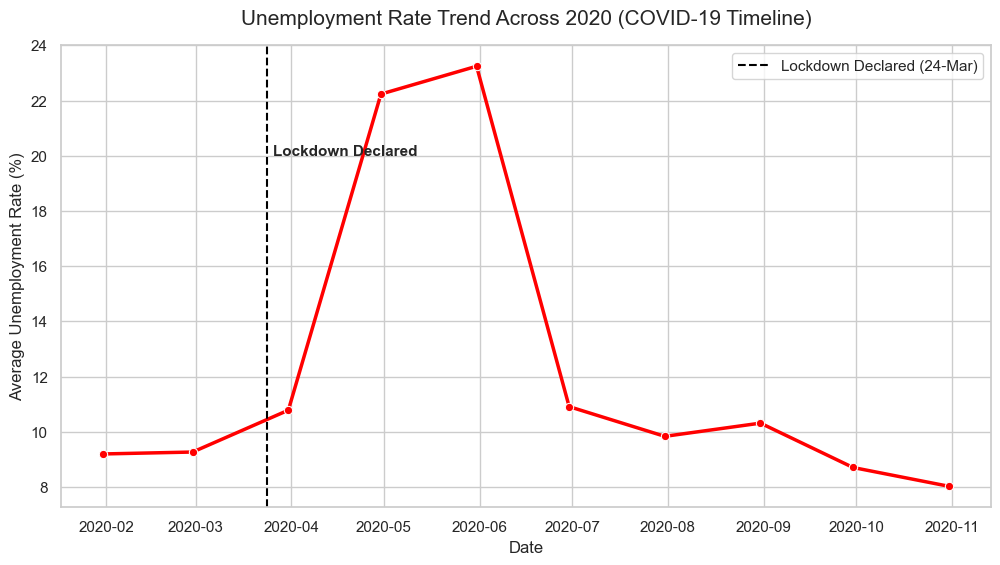

In [10]:
# Timeline of Unemployment Rate in 2020 (using df_rate)
plt.figure(figsize=(12, 6))
timeline = df_rate.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
sns.lineplot(data=timeline, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='red', linewidth=2.5)

# Mark lockdown start
plt.axvline(x=pd.Timestamp('2020-03-24'), color='black', linestyle='--', label='Lockdown Declared (24-Mar)')
plt.text(pd.Timestamp('2020-03-26'), 20, 'Lockdown Declared', fontsize=11, fontweight='bold')

plt.title("Unemployment Rate Trend Across 2020 (COVID-19 Timeline)", fontsize=15, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Unemployment Rate (%)", fontsize=12)
plt.legend()
plt.savefig("unemployment_timeline_2020.png", dpi=300, bbox_inches="tight")
plt.show()

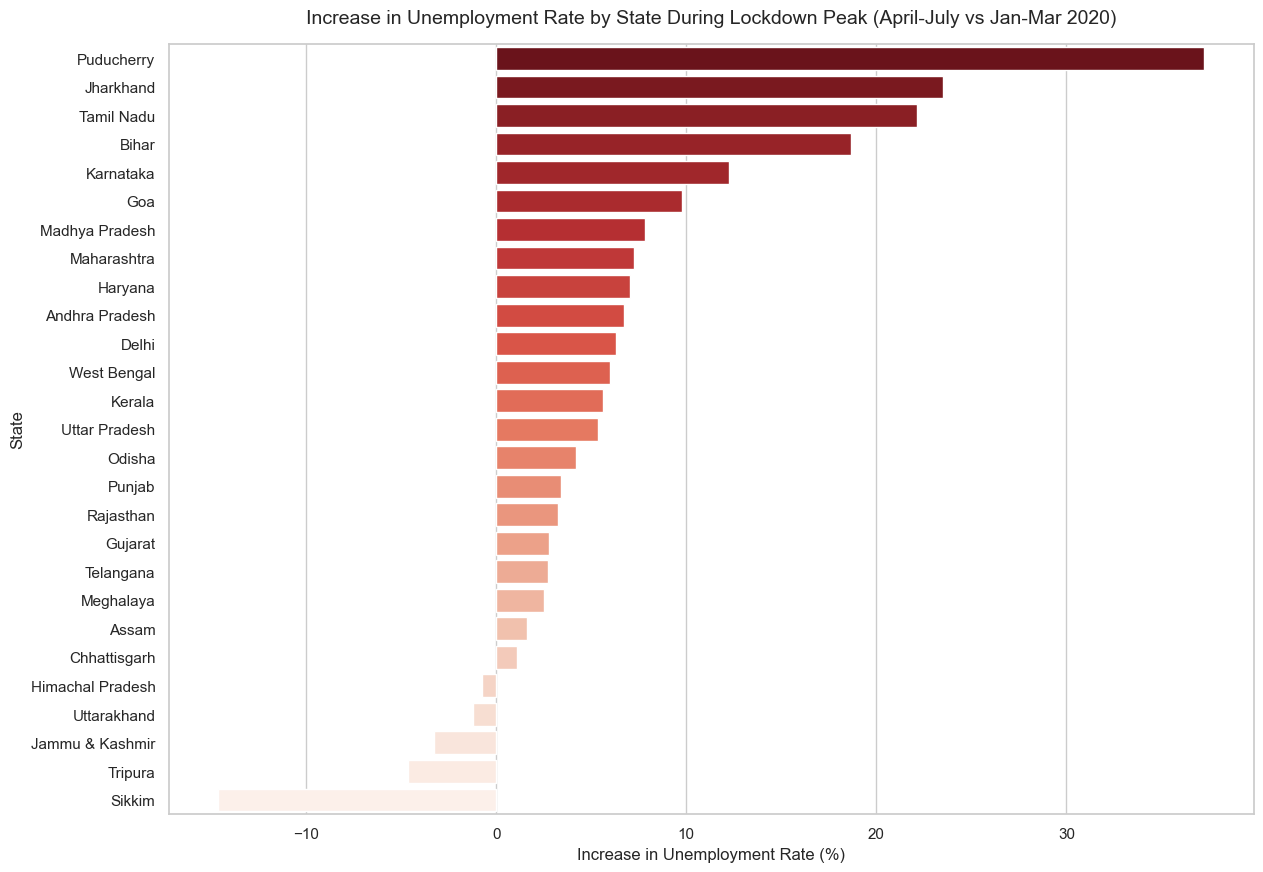

Top 5 States with the highest increase in unemployment during lockdown:
Period      Region  Pre-Lockdown  Lockdown Peak  Unemployment Increase (%)
17      Puducherry      1.180000        38.4375                  37.257500
10       Jharkhand     10.230000        33.7250                  23.495000
21      Tamil Nadu      3.353333        25.5000                  22.146667
2            Bihar     12.110000        30.8025                  18.692500
11       Karnataka      3.310000        15.5650                  12.255000


In [11]:
# State-wise contrast: Pre-Lockdown vs Lockdown Peak
state_lockdown = df_rate.groupby(['Region', 'Period'])['Estimated Unemployment Rate (%)'].mean().unstack().reset_index()
state_lockdown['Unemployment Increase (%)'] = state_lockdown['Lockdown Peak'] - state_lockdown['Pre-Lockdown']
state_lockdown = state_lockdown.sort_values(by='Unemployment Increase (%)', ascending=False)

plt.figure(figsize=(14, 10))
sns.barplot(data=state_lockdown, y='Region', x='Unemployment Increase (%)', palette='Reds_r', hue='Region', legend=False)
plt.title("Increase in Unemployment Rate by State During Lockdown Peak (April-July vs Jan-Mar 2020)", fontsize=14, pad=15)
plt.xlabel("Increase in Unemployment Rate (%)", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.savefig("state_unemployment_increase_lockdown.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top 5 States with the highest increase in unemployment during lockdown:")
print(state_lockdown[['Region', 'Pre-Lockdown', 'Lockdown Peak', 'Unemployment Increase (%)']].head(5))